In [1]:
import numpy as np 
import scipy.stats as sts 
import scipy.special as sc 
import matplotlib.pyplot as plt 
%matplotlib inline
import sympy as sp

# Гречишкин Денис ПМ-31, лабораторная работа №1

# Часть 1.4 (для совместного обсуждения)

## пример 1

изучим нормально распределенную случайную величину с параметрами a = 2, b = 4
для начала построим графики функции и плотности распределения

нормальное распределение с параметрами: 
 a =  2 и b =  4


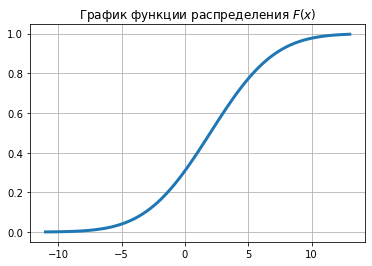

In [2]:
a_n = 2
b_n = 4
raspred = sts.norm(a_n, b_n)
print('нормальное распределение с параметрами:',
      '\n', 'a = ', a_n, 'и' ,'b = ', b_n)

#вводим функцию распределения
x_n = np.linspace(-11, 13, 100)
F_x_n = raspred.cdf(x_n)
plt.plot(x_n, F_x_n, lw = 3)
plt.title('График функции распределения $F(x)$')
plt.grid(True)

построим функцию плотности распределения

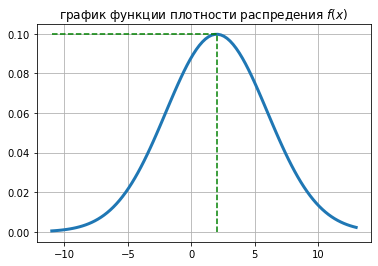

In [3]:
#плотность распределения
x_n = np.linspace(-11, 13, 100)
f_x_n = raspred.pdf(x_n)
plt.plot(x_n, f_x_n, lw = 3)
plt.title('график функции плотности распредения $f(x)$')
plt.vlines(a_n, 0, raspred.pdf(a_n), color = 'g', linestyle = 'dashed')
plt.hlines(raspred.pdf(a_n), -11, a_n, color = 'g', linestyle = 'dashed')
plt.grid(True)

найдем вероятность попадания в интервал с помощью формулы $$P(x_1<X<x_2) = P(X=x_2) - P(X=x_1)$$

In [4]:
#вреоятность попадания в интервал (x1, x2)
x1 = -2
x2 = 4
print('x1 = ', x1, 'x2 = ', x2)
p1_x1_x2 = raspred.cdf(x2) - raspred.cdf(x1)
print('Вероятность попадания в интервал \
(x1, x2) через функцию распределения',
      '\n', 'P{x1<X<x2} = ', p1_x1_x2)

from scipy import integrate
f_n = lambda x: raspred.pdf(x)
p2_x1_x2 = integrate.quad(f_n, x1, x2)
print('Вероятность попадания в интервал \
(x1, x2) через плотность распределения ', 
      '\n', 'P{x1<X<x2} = ', p2_x1_x2)

x1 =  -2 x2 =  4
Вероятность попадания в интервал (x1, x2) через функцию распределения 
 P{x1<X<x2} =  0.532807207342556
Вероятность попадания в интервал (x1, x2) через плотность распределения  
 P{x1<X<x2} =  (0.532807207342556, 5.915348292779355e-15)


вычислим квантили с помощью встроенных функций

In [5]:
#вычисление квантилей
print('Квантиль порядка 0.5 равна', raspred.ppf(0.5))
print('Медиана равна', raspred.median())
print('Квантиль порядка 0.9 равна', raspred.ppf(0.9))

Квантиль порядка 0.5 равна 2.0
Медиана равна 2.0
Квантиль порядка 0.9 равна 7.1262062621784015


теперь найдем числовые характеристики двумя способами

In [6]:
#вычисление числовых характеристик в python
print('Мат. ожидание равно:', raspred.mean())
print('Дисперсия равна:', raspred.var())
print('СКО равно:', raspred.std())
print('Нач. момент 1го порядка:', raspred.moment(1))
print('Нач. момент 2го порядка:', raspred.moment(2))

from statsmodels.sandbox.distributions.sppatch import expect_v2
m2 = expect_v2(sts.norm, fn = lambda x: (x - a_n)**2, loc = a_n, scale = b_n)
m3 = expect_v2(sts.norm, fn = lambda x: (x - a_n)**3, loc = a_n, scale = b_n)
print('Центр. момент 2го порядка:', m2)
print('Центр. момент 3го порядка:', m3)

Мат. ожидание равно: 2.0
Дисперсия равна: 16.0
СКО равно: 4.0
Нач. момент 1го порядка: 2.0
Нач. момент 2го порядка: 20.0


C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


Центр. момент 2го порядка: 15.99999878641433
Центр. момент 3го порядка: -8.002502078790202e-13


In [7]:
m, v, s, k = raspred.stats('mvsk')
print('Поиск числовых характеристик другим способом:', '\n', 
      'Мат. ожидание равно:', m, '\n', 'Дисперсия равна:', v, 
      '\n', 'ассиметрия равна:', s, '\n', 'эксцесс:', k)

Поиск числовых характеристик другим способом: 
 Мат. ожидание равно: 2.0 
 Дисперсия равна: 16.0 
 ассиметрия равна: 0.0 
 эксцесс: 0.0


In [8]:
f_m2 = lambda x: (raspred.pdf(x) * (x - a_n)**2)
m2 = integrate.quad(f_m2, -np.inf, np.inf)
print('Центр. момент 2го порядка:', m2[0])

Центр. момент 2го порядка: 15.99999999999999


## Пример 2: изучимм биномиальное распределение

In [9]:
print('БИНОМИАЛЬНЫЙ ЗАКОН РАСПРЕДЕЛЕНИЯ')
n = 3
p = 0.25
print('Значения параметров:','\n', 'n =', n, 'и', 'p =', p)

raspred = sts.binom(n, p)

БИНОМИАЛЬНЫЙ ЗАКОН РАСПРЕДЕЛЕНИЯ
Значения параметров: 
 n = 3 и p = 0.25


запишем ряд распределения

In [10]:
xkd = list(range(n + 1))
pkd = [sc.comb(n, i) * p**i * (1 - p)**(n-i) for i in xkd]
print('ряд распределения (использование формул):')
print('xkd \t pkd')
for k in range(n+1):
    print(xkd[k], '\t', pkd[k])

ряд распределения (использование формул):
xkd 	 pkd
0 	 0.421875
1 	 0.421875
2 	 0.140625
3 	 0.015625


построим ряд распределения используя класс в python

In [11]:
xk = list(range(n + 1))
pk = [raspred.pmf(i) for i in xk]
print('Ряд распределения:')
print('xk \t pk')
for k in range(n+1):
    print(xk[k], '\t', pk[k])

Ряд распределения:
xk 	 pk
0 	 0.421875
1 	 0.421875
2 	 0.14062499999999994
3 	 0.015625


Визуализируем ряд распределения

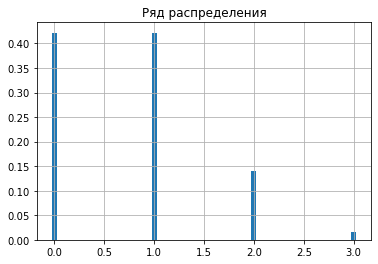

In [12]:
plt.bar(xk, pk, width = 0.05)
plt.title('Ряд распределения')
plt.grid(True)

Построим график функции распределения

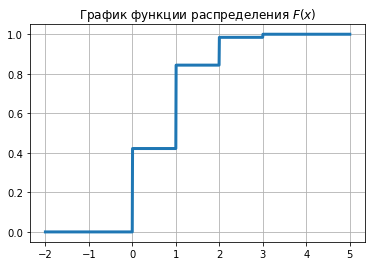

In [13]:
x_n = np.linspace(-2, 5, 1000)
F_x_n = raspred.cdf(x_n)
plt.plot(x_n, F_x_n, lw = 3)
plt.title('График функции распределения $F(x)$')
plt.grid(True)

выбрав конкретный числовой интервал, найдем вероятность попадания в него нашей случайной величины

In [14]:
x1 = -2
x2 = 1.5
print('x1 =', x1, 'x2 =', x2)
p1_x1_x2 = raspred.cdf(x2) - raspred.cdf(x1)
print('вероятность попадания в интервал (x1, x2)', 
      '\n', 'P{x1 < X < x2} =', p1_x1_x2)

x1 = -2 x2 = 1.5
вероятность попадания в интервал (x1, x2) 
 P{x1 < X < x2} = 0.84375


вычисление начальных и центральных моментов

In [15]:
print('Мат. ожидание равно:', raspred.mean())
print('Дисперсия равна:', raspred.var())
print('СКО равно:', raspred.std())
print('Нач. момент 1го порядка:', raspred.moment(1))
print('Нач. момент 2го порядка:', raspred.moment(2))

Мат. ожидание равно: 0.75
Дисперсия равна: 0.5625
СКО равно: 0.75
Нач. момент 1го порядка: 0.75
Нач. момент 2го порядка: 1.125


другой способ поиска мат ожидания и дисперсии

In [16]:
mean, var = raspred.stats()
print('Поиск числовых характеристик другим способом:', 
      '\n', 'Мат. ожидание равно:', mean, 
      '\n', 'Дисперсия равна:', var)

Поиск числовых характеристик другим способом: 
 Мат. ожидание равно: 0.75 
 Дисперсия равна: 0.5625


вычисление нач. моментов непосредственно по формулам

In [17]:
xkm = np.array(xk)
pkm = np.array(pk)
mean_d = np.sum(xkm*pkm)
print('Мат. ожидание(подсчет по формуле)', mean_d)
a2_d = np.sum(xkm**2*pkm)
print('Нач. момент 2го порядка (подсчет по формуле)', a2_d)
m2_d = np.sum((xkm - mean_d)**2*pkm)
print('Центральный момент 2го порядка (подсчет по формуле)', m2_d)

Мат. ожидание(подсчет по формуле) 0.7499999999999999
Нач. момент 2го порядка (подсчет по формуле) 1.1249999999999998
Центральный момент 2го порядка (подсчет по формуле) 0.5624999999999999


проиллюстрируем локальную теорему Муавра-Лапласа

Погрешность вычисления вероятностей с использованиемнормального закона: 0.008218080291952964


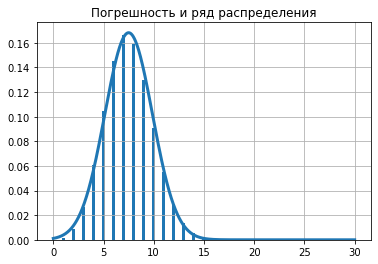

In [18]:
n1 = 30
p = 0.25
raspred_b = sts.binom(n1, p)
xk_b = list(range(n1 + 1))
pk_b = [raspred_b.pmf(i) for i in xk_b]
#визуализируем ряд распределения
plt.bar(xk_b, pk_b, width = 0.3)
#построим график плотности нормального распределения
raspred_norm = sts.norm(n1 * p, np.sqrt(n1 * p * (1 - p)))
x = np.linspace(0, n1, 1000)
f_x_norm = raspred_norm.pdf(x)
plt.plot(x, f_x_norm, lw = 3)
plt.title('Погрешность и ряд распределения')
plt.grid(True)
fk_norm = [raspred_norm.pdf(i) for i in xk_b]
pk_b_array = np.asarray(pk_b)
fk_norm_array = np.asarray(fk_norm)
print('Погрешность вычисления вероятностей с использованием\
нормального закона:', np.abs(np.max(pk_b_array - fk_norm_array)))

# Часть 1.5 (ПРИМЕРЫ ДЛЯ САМОСТОЯТЕЛНОГО РЕШЕНИЯ)

## Задание 1.24.  Проекция 𝑋 радиуса-вектора случайной точки окружности радиуса 4 на диаметр имеет функцию распределения (закон арксинуса) $$\left\{\begin{aligned}0, x \le 4; \\ \frac{1}{2} + \frac{1}{\pi}arcsin(\frac{x}{4}), -4 < x < 4 \\1, x \ge 4 \end{aligned}\right.$$

1) Найдите плотность распределения случайной величины и постройте её график. 
2) Найдите моду, медиану, математическое ожидание, дисперсию, квантили порядков 0,25 и 0,75, начальные моменты 2-го и 3-го порядков. 
3) Найдите вероятность того, что случайная величина отклонится  от математического ожидания менее, чем на 2. 

## Решение: 
Пункт 1: 
Мы знаем что функция распределения непрерывной случайной величины и её плотность распределения связаны следующим свойством:
$$F_X(x) =  \int_{-\infty}^{x} f_X(t)dt$$
$$(F_X(x))'|_{x = x_0} = f_X(x_0)$$

Тогда разобъем исходную функцию распределения на 3 части: при x $\le$ 4; при x $\le$ 4 и при x $\le$ 4. Каждую из функций продифференцируем с помощью соответствующей функции из модуля sympy и построим график каждой из частей на соответствующих промежутках в одной системе координат

In [19]:
x = sp.symbols('x')
F1 = 0*x
F2 = 0.5 + sp.asin(x/4)/sp.pi
F3 = 1*x**0
f1 = sp.diff(F1, x)
f2 = sp.diff(F2, x)
f3 = sp.diff(F3, x)
#очевидно что f1 и f3 равняются нулю, убедимся в этом
print('f1 =', f1)
print('f3 =', f3)

f1 = 0
f3 = 0


теперь проверим что производная F2 взята верно:
$$(\frac{1}{2} + \frac{1}{\pi}arcsin(\frac{x}{4}))' = \frac{1}{\pi} \cdot \frac{1}{4} \frac{1}{\sqrt{1-\frac{x^2}{16}}} $$

In [20]:
f2

1/(4*pi*sqrt(1 - x**2/16))

Все производные посчитаны верно. Теперь построим график найденной плотности распределения. 

C:\Users\Администратор\AppData\Local\Temp\ipykernel_11508\3677201315.py:5: RuntimeWarning: divide by zero encountered in true_divide
  f02 = 1/(4*np.pi*np.sqrt(1-((x2**2)/16)))


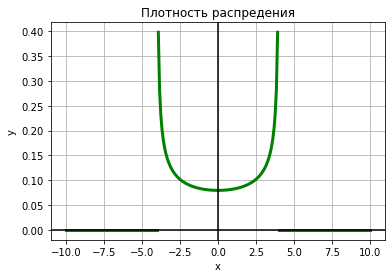

In [21]:
x1 = np.linspace(-10, -4, 100)
x2 = np.linspace(-4, 4, 100)
x3 = np.linspace(4, 10, 100)
f01 = 0*x1**0
f02 = 1/(4*np.pi*np.sqrt(1-((x2**2)/16)))
f03 = 0*x3*0
plt.plot(x1, f01, lw = 3, color = 'g')
plt.plot(x2, f02, lw = 3, color = 'g')
plt.plot(x3, f03, lw = 3, color = 'g')
plt.axvline(x = 0, color = "k")
plt.axhline(y = 0, color = "k")
plt.xlabel("x")
plt.ylabel("y")
plt.title('Плотность распредения')
plt.grid(True)

Пункт 2: Найдите моду, медиану, математическое ожидание, дисперсию, 
квантили порядков 0,25 и 0,75, начальные моменты 2-го и 3-го порядков. 

Для нахождения всех характеристик, указанных в условии, используем стандартные формулы:

Можно сразу заметить что т.к график уходит в бесконечность, то моды нет

1. Мат.ожидание: $$M[X] = \int_{-\infty}^{\infty}x \cdot f_X(x)dx$$т.к f1=f3=0, то достаточно посчитать интеграл от $x\cdot f_2(x)$ в пределах от -4 до 4

In [22]:
x = sp.Symbol('x')
m = sp.integrate(x*f2, (x, -4, 4))
print('мат ожидание равно', m)

мат ожидание равно 0


2. Дисперсия: $$D[X] = \int_{-\infty}^{\infty}(x - m_x)^2 \cdot f_X(x)dx$$т.к f1=f3=0, то достаточно посчитать интеграл от $(x - m_x)^2\cdot f_2(x)$ в пределах от -4 до 4

In [23]:
x = sp.Symbol('x')
D = sp.integrate(x**2*f2, (x, -4, 4))
print('дисперсия равна', D)

дисперсия равна 8


3. Начальные моменты: $$\alpha_k = \int_{-\infty}^{\infty}x^k \cdot f_X(x)dx$$т.к f1=f3=0, то достаточно посчитать интегралы от $x^k\cdot f_2(x)$ в пределах от -4 до 4

In [24]:
x = sp.Symbol('x')
alpha2 = sp.integrate(x**2*f2, (x, -4, 4))
alpha3 = sp.integrate(x**3*f2, (x, -4, 4))
print('нач момент 2 порядка равен', alpha2)
print('нач момент 3 порядка равен', alpha3)

нач момент 2 порядка равен 8
нач момент 3 порядка равен 0


4. Квантили: Квантиль порядка p это такое число $x_p$ что $$F_X(x_p) = p$$ Их мы найдем используя метод solve библиотеки sympy. 

In [25]:
x = sp.Symbol('x')
p1 = 0.25
p2 = 0.75
#в данном случае решаем уравнение 0.5 + asin(x/4)/pi - 0.25 = 0
xp1 = sp.solve(F2 - p1, x)
xp2 = sp.solve(F2 - p2, x)
print('Квантиль порядка 0,25 равна', xp1)
print('Квантиль порядка 0,75 равна', xp2)

Квантиль порядка 0,25 равна [-2.82842712474619]
Квантиль порядка 0,75 равна [2.82842712474619]


Пункт 3: Найдите вероятность того, что случайная величина отклонится 
от математического ожидания менее, чем на 2

Известно что для равномерного распределения действительно следующее равенство:
$$P(|X-m_x|<\epsilon) = \int_{m_X - \epsilon}^{m_X + \epsilon}f_X(x)dx$$ т.к f1=f3=0, то достаточно посчитать интегралы от $f_2(x)$ в пределах от $m_X - \epsilon$ до $m_X + \epsilon$

In [26]:
epsilon = 2
x = sp.Symbol('x')
P = sp.integrate(f2, (x, m-epsilon, m+epsilon))
print('вероятность того, что случайная величина отклонится\
от математического ожидания менее, чем на 2, равна', P)

вероятность того, что случайная величина отклонитсяот математического ожидания менее, чем на 2, равна 1/3


## Задание 2.24: Для распределения хи-квадрат для четырёх значений параметра (выберите их сами) выполните следующее: 
1) постройте в одной системе координат графики плотностей распределений; 
2) постройте в одной системе координат графики функций распределений; 
3) постройте в одной системе координат графики зависимости квантилей от их порядка. 

Решение: 
возьмем в качестве четырёх значений для хи-квадрат $n_1 = 3; n_2 = 5; n_3 = 7; n_4 = 9$

In [27]:
n1 = 3
n2 = 5
n3 = 7
n4 = 9
#Вводим 4 распределения хи-квадрат
raspred1 = sts.chi2(n1)
raspred2 = sts.chi2(n2)
raspred3 = sts.chi2(n3)
raspred4 = sts.chi2(n4)

Пункт 1: т.к распределение хи-квадрат стандартное, то для нахождения плотностей распределения, воспользуемся встроенной функцией R(params).pdf(x) (здесь R – обозначение типа закона распределения, params – параметры распределения) и с помощью функции plt.plot построим графики плотностей распределения

Text(0.5, 1.0, 'графики функций плотностей распредения')

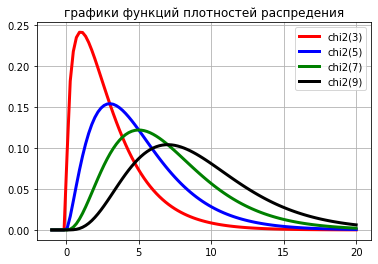

In [28]:
x_n = np.linspace(-1, 20, 100)
f_x_n_1 = raspred1.pdf(x_n)
f_x_n_2 = raspred2.pdf(x_n)
f_x_n_3 = raspred3.pdf(x_n)
f_x_n_4 = raspred4.pdf(x_n)

handle1, = plt.plot(x_n, f_x_n_1, lw = 3, color = 'r', label = 'chi2(3)')
handle2, = plt.plot(x_n, f_x_n_2, lw = 3, color = 'b', label = 'chi2(5)')
handle3, = plt.plot(x_n, f_x_n_3, lw = 3, color = 'g', label = 'chi2(7)')
handle4, = plt.plot(x_n, f_x_n_4, lw = 3, color = 'k', label = 'chi2(9)')
plt.legend(handles=[handle1, handle2, handle3, handle4])
plt.grid(True)
plt.title('графики функций плотностей распредения')

Пункт 3: т.к распределение хи-квадрат стандартное, то для нахождения значений квантилей воспользуемся встроенной функцией R(params).ppf(q) (здесь R – обозначение типа закона распределения, params – параметры распределения, q - порядок квантили) и с помощью функции plt.plot построим необходимые зависимости

Text(0.5, 1.0, 'графики зависимостей квантилей от порядка')

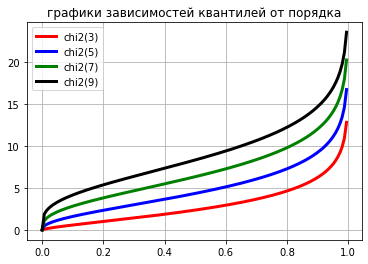

In [29]:
ps = np.linspace(0, 7, 1000)
Qs1 = raspred1.ppf(ps)
Qs2 = raspred2.ppf(ps)
Qs3 = raspred3.ppf(ps)
Qs4 = raspred4.ppf(ps)

handle1, = plt.plot(ps, Qs1, lw = 3, color = 'r', label = 'chi2(3)')
handle2, = plt.plot(ps, Qs2, lw = 3, color = 'b', label = 'chi2(5)')
handle3, = plt.plot(ps, Qs3, lw = 3, color = 'g', label = 'chi2(7)')
handle4, = plt.plot(ps, Qs4, lw = 3, color = 'k', label = 'chi2(9)')
plt.legend(handles=[handle1, handle2, handle3, handle4])
plt.grid(True)
plt.title('графики зависимостей квантилей от порядка')

## Задание 3: 
1) Для четырёх случайных величин $\sum \limits_{i = 1} ^{k} X_i$ где $X_i \sim Pu(1)$
- визуализируйте ряды распределения;  
- постройте графики функций распределения; 
- найдите вероятности отклонения от математического ожидания более чем на три средних квадратичных отклонения. 
2) Визуализируйте (проиллюстрируйте графически) асимптотическую нормальность закона Пуассона.

## Решение: 
Мы знаем, что закон Пуассона композиционно устойчив, причем так, что если $X \sim Pu(\lambda_1)$ и $Y \sim Pu(\lambda_2)$ то $X+Y \sim (\lambda_1 + \lambda_2)$

Тогда получаем что:$$X_1 \sim Pu(1) \newline
X_1 + X_2 \sim Pu(2) \newline
X_1 + X_2 + X_3 \sim Pu(3) \newline
X_1 + X_2 + X_3 + X_4 \sim Pu(4) \newline
X_1 + X_2 + X_3 + X_4 + X_5 \sim Pu(5)$$

Введем эти случайный величины и с помощью функции raspred.pmf найдем ряды распределения и посмотрим соответствеющие графики.$\newline$ Чтобы не разбивать код на несколько разных ячеек, запишем все распределения в массив

Ряд распределения случайной величины, распределённой     по пуассоновому закону с параметром 1 :
xks 	 pks
0 	 0.36787944117144233
1 	 0.36787944117144233
2 	 0.18393972058572114
3 	 0.06131324019524039
4 	 0.015328310048810101
5 	 0.00306566200976202
6 	 0.0005109436682936698


Ряд распределения случайной величины, распределённой     по пуассоновому закону с параметром 2 :
xks 	 pks
0 	 0.1353352832366127
1 	 0.2706705664732254
2 	 0.2706705664732254
3 	 0.18044704431548356
4 	 0.09022352215774178
5 	 0.03608940886309672
6 	 0.012029802954365565


Ряд распределения случайной величины, распределённой     по пуассоновому закону с параметром 3 :
xks 	 pks
0 	 0.049787068367863944
1 	 0.14936120510359185
2 	 0.22404180765538775
3 	 0.22404180765538775
4 	 0.16803135574154085
5 	 0.10081881344492458
6 	 0.05040940672246224


Ряд распределения случайной величины, распределённой     по пуассоновому закону с параметром 4 :
xks 	 pks
0 	 0.01831563888873418
1 	 0.07326255555493673
2 	 0.146525

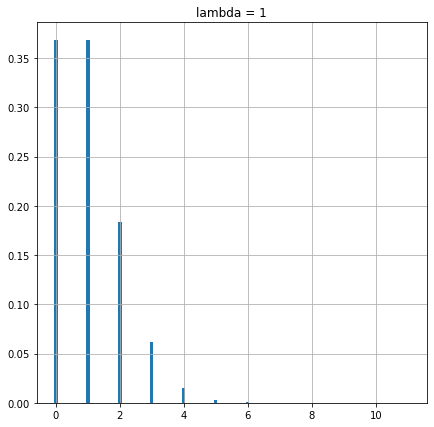

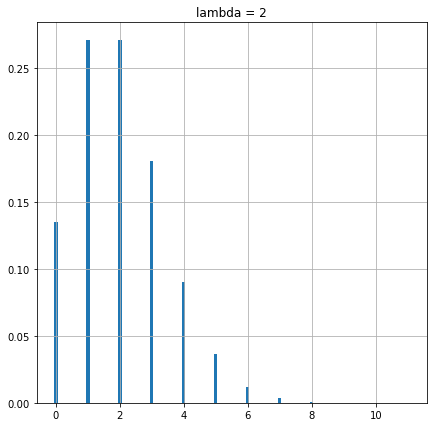

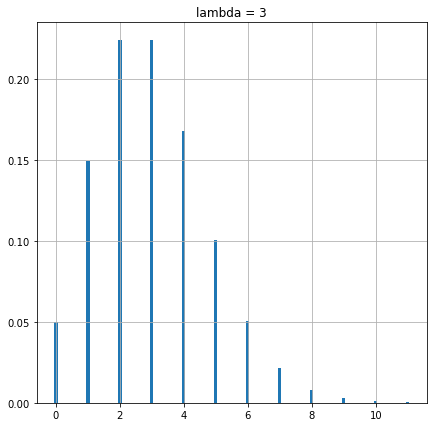

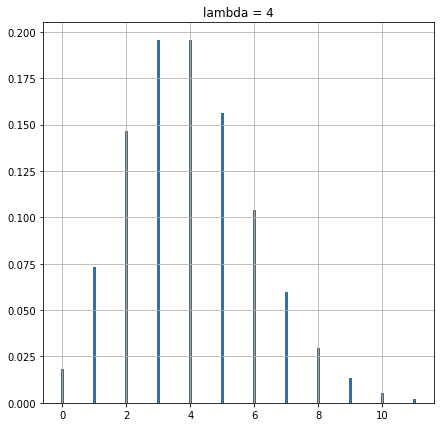

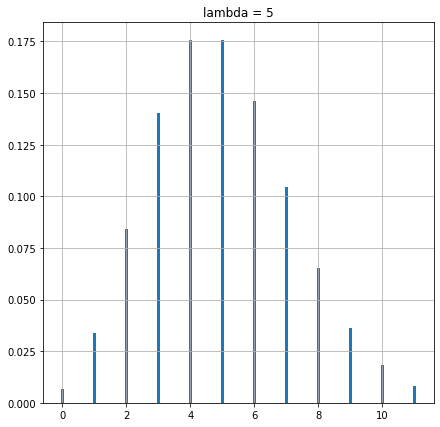

In [30]:
Raspred_X = sts.poisson(1)#Распределение случайной величины X = X_1
Raspred_Y = sts.poisson(2)#Распределение случайной величины Y = X_1 + X_2
Raspred_Z = sts.poisson(3)#Распределение случайной величины Z = X_1 + X_2 + X_3
Raspred_T = sts.poisson(4)#Распределение случайной величины T = X_1 + ... + X_4
Raspred_K = sts.poisson(5)#Распределение случайной величины K = X_1 + ... + X_5
RASPREDS = [Raspred_X, Raspred_Y, Raspred_Z, Raspred_T, Raspred_K]
n = 6
i = 1


#чтобы все гистограммы были в одном и том же масштабе 
#и гистограммы для распределений с параметрами 4 и 5 были 
#более наглядными, я расширил диапазон аргументов для 
#всех распределений и увеличил ширину столбцов гистограмм

for raspred in RASPREDS:
    xks = list(range(n + 6))
    pks = [raspred.pmf(i) for i in xks]
    print('Ряд распределения случайной величины, распределённой \
    по пуассоновому закону с параметром', i, ':')
    print('xks \t pks')
    for k in range(n+1):
        print(xks[k], '\t', pks[k])
    print('\n')
    plt.figure(figsize = (7, 7))
    plt.bar(xks, pks, width = 0.1)
    plt.title(f'lambda = {i}')
    plt.grid(True)
    i+=1

Теперь построим графики функций распределения функций распределения. Будем это делать аналогично предыдущему заданию - с помощью функций cdf и plt.plot

Text(0.5, 1.0, 'графики функций распредения')

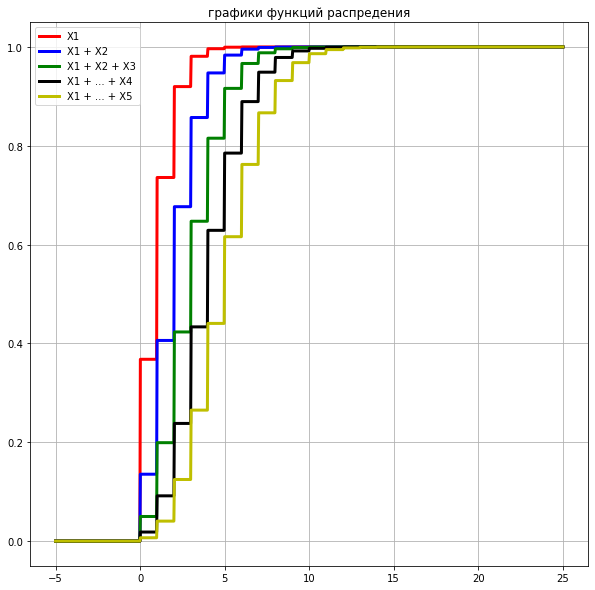

In [31]:
x_n = np.linspace(-5, 25, 1000)
F_x_1 = Raspred_X.cdf(x_n)
F_x_2 = Raspred_Y.cdf(x_n)
F_x_3 = Raspred_Z.cdf(x_n)
F_x_4 = Raspred_T.cdf(x_n)
F_x_5 = Raspred_K.cdf(x_n)

plt.figure(figsize = (10, 10))
handle1, = plt.plot(x_n, F_x_1, lw = 3, color = 'r', label = 'X1')
handle2, = plt.plot(x_n, F_x_2, lw = 3, color = 'b', label = 'X1 + X2')
handle3, = plt.plot(x_n, F_x_3, lw = 3, color = 'g', label = 'X1 + X2 + X3')
handle4, = plt.plot(x_n, F_x_4, lw = 3, color = 'k', label = 'X1 + ... + X4')
handle5, = plt.plot(x_n, F_x_5, lw = 3, color = 'y', label = 'X1 + ... + X5')
plt.legend(handles=[handle1, handle2, handle3, handle4, handle5])
plt.grid(True)
plt.title('графики функций распредения')

Найдем основные числовые характеристики случайной величины X_1 с помощью встроенных функций R.mean и R.var (R - распределение с заданными параметрами). $\newline$ 
Далее, используя их, с помощью формулы $P(|X - m_X| > 3\sigma) = 1 - (P(X=m_X + 3\sigma) - P(X=m_X - 3\sigma) + P(X = m_X - 3\sigma))$ и функции R(params).cdf(x) (R - распределение, params - параметры) найдем искомые вероятности

In [32]:
i = 1
for raspred in RASPREDS:
    m = raspred.mean()
    sigma = np.sqrt(raspred.var())
    #исправлена формула подсчета вероятностей
    p_ans = 1 - (raspred.cdf(m + 3*sigma) - \
    raspred.cdf(m - 3*sigma - 1))
    print(f'вероятность попадания в интервал (m_x - 3*sigma, m_x + 3*sigma)\
    для {i}-й случайной величины', '\n', 
          'P{m_x - 3*sigma < X < m_x + 3*sigma} =', p_ans, '\n')
    i+=1

вероятность попадания в интервал (m_x - 3*sigma, m_x + 3*sigma)    для 1-й случайной величины 
 P{m_x - 3*sigma < X < m_x + 3*sigma} = 0.00365984682734366 

вероятность попадания в интервал (m_x - 3*sigma, m_x + 3*sigma)    для 2-й случайной величины 
 P{m_x - 3*sigma < X < m_x + 3*sigma} = 0.004533805526248824 

вероятность попадания в интервал (m_x - 3*sigma, m_x + 3*sigma)    для 3-й случайной величины 
 P{m_x - 3*sigma < X < m_x + 3*sigma} = 0.0038029920616760027 

вероятность попадания в интервал (m_x - 3*sigma, m_x + 3*sigma)    для 4-й случайной величины 
 P{m_x - 3*sigma < X < m_x + 3*sigma} = 0.0028397661205137315 

вероятность попадания в интервал (m_x - 3*sigma, m_x + 3*sigma)    для 5-й случайной величины 
 P{m_x - 3*sigma < X < m_x + 3*sigma} = 0.005453091913009356 



Пункт 2: Теперь проиллюстрируем асимптотическую нормальность закона Муавра-Лапласа на примере случайной $X_1 + ... + X_5$. Для этого составим и визуализируем ряд распределения и функция распределения

Ряд распределения: lambda = 1
xks 	 pks
0 	 0.36787944117144233
1 	 0.36787944117144233
2 	 0.18393972058572114
3 	 0.06131324019524039
4 	 0.015328310048810101
5 	 0.00306566200976202
6 	 0.0005109436682936698
7 	 7.299195261338139e-05
8 	 9.123994076672672e-06
9 	 1.013777119630298e-06
10 	 1.0137771196302987e-07
11 	 9.216155633002698e-09
12 	 7.680129694168931e-10
13 	 5.907792072437641e-11
14 	 4.219851480312585e-12
15 	 2.813234320208389e-13


Ряд распределения: lambda = 2
xks 	 pks
0 	 0.1353352832366127
1 	 0.2706705664732254
2 	 0.2706705664732254
3 	 0.18044704431548356
4 	 0.09022352215774178
5 	 0.03608940886309672
6 	 0.012029802954365565
7 	 0.0034370865583901616
8 	 0.0008592716395975402
9 	 0.00019094925324389823
10 	 3.818985064877954e-05
11 	 6.943609208869007e-06
12 	 1.1572682014781705e-06
13 	 1.7804126176587247e-07
14 	 2.543446596655316e-08
15 	 3.3912621288737476e-09


Ряд распределения: lambda = 3
xks 	 pks
0 	 0.049787068367863944
1 	 0.14936120510359185
2 	 0

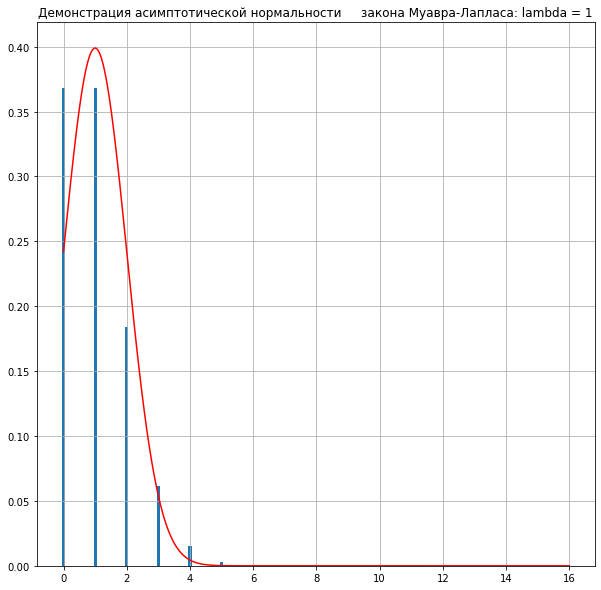

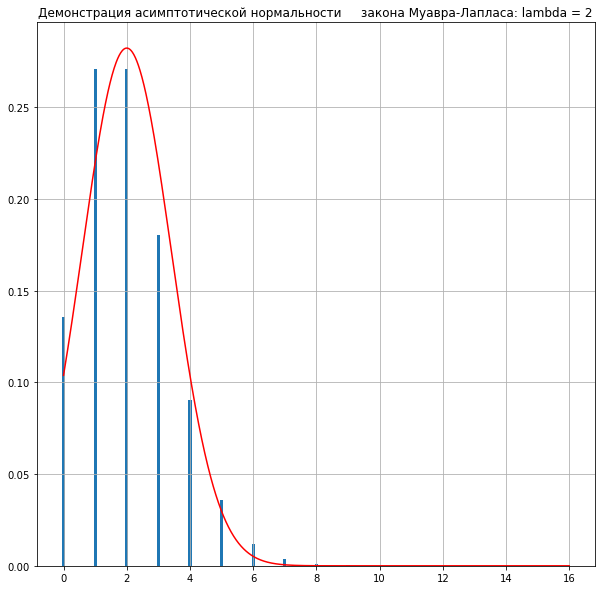

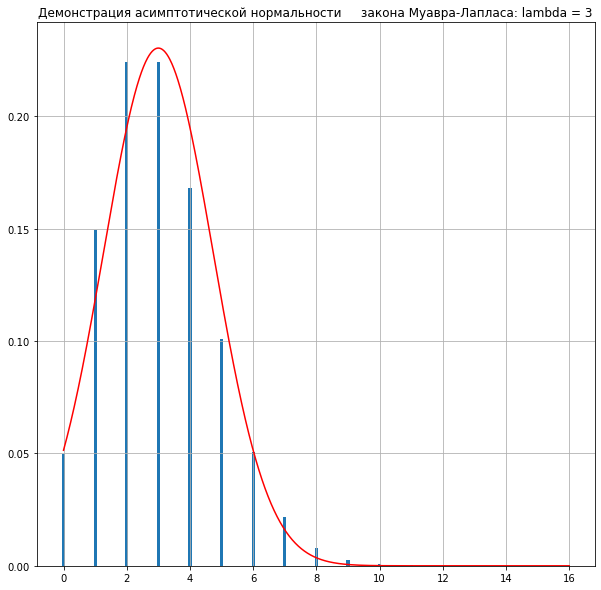

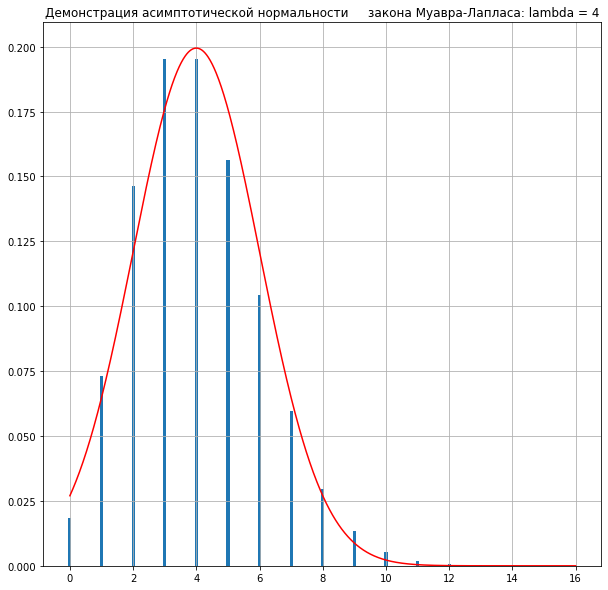

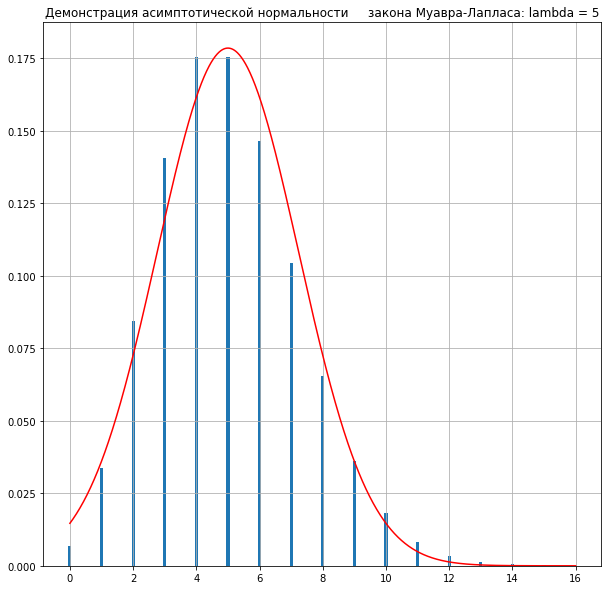

In [33]:
#возьмем достаточно большое lambda
Lambda = 1
n = 15
for raspred in RASPREDS:
    #составляем ряд распределения
    xks = list(range(n + 1))
    pks = [raspred.pmf(i) for i in xks]
    print(f'Ряд распределения: lambda = {Lambda}')
    print('xks \t pks')
    for k in range(n+1):
        print(xks[k], '\t', pks[k])
    print('\n')
        
    #Составим плотность нормального распределения
    NORM_RASP = sts.norm(Lambda, np.sqrt(Lambda))
    x = np.linspace(0, n+1, 1000)
    f_x = NORM_RASP.pdf(x)
    
    #построим ряд и плотность нормального распределения на одном графике
    plt.figure(figsize = (10, 10))
    plt.bar(xks, pks, width = 0.1)
    plt.plot(x, f_x, color = 'r')
    plt.grid(True)
    plt.title(f'Демонстрация асимптотической нормальности \
    закона Муавра-Лапласа: lambda = {Lambda}')
    
    Lambda+=1

## Задание 4: 
1) На примере нескольких распределений проиллюстрируйте связь между значением коэффициента асимметрии и характерными особенностями графика плотности распределения. Как можно ответить на вопрос: «Что характеризует коэффициент асимметрии?» 
2) На примере нескольких распределений проиллюстрируйте связь между значением коэффициента эксцесса и характерными особенностями графика плотности распределения. Как можно ответить на вопрос: «Что характеризует коэффициент эксцесса?»

## Решение
Рассмотрим нормальный закон распределения и равномерный закон распределения: для каждого из этих распределений возьмем разные параметры, найдем коэффициенты асимметрии и эксцесса и построим графики функций плотностей распределения.

Сначала посмотрим на равномерное распределение: введём случайные величины $X_1, X_2$ и $X_3$: $$X_1 \sim R(1, 2) \newline X_2 \sim R(3, 11) \newline R_3 \sim N(-3, 5)$$

In [34]:
x = np.linspace(-40, 40, 1000)

X_1 = sts.uniform(1, 2)
X_2 = sts.uniform(3, 11)
X_3 = sts.uniform(-3, 5)

sk1 = X_1.stats('mvsk')[:2]
sk2 = X_2.stats('mvsk')[:2]
sk3 = X_3.stats('mvsk')[:2]

Raspred_1 = X_1.pdf(x)
Raspred_2 = X_2.pdf(x)
Raspred_3 = X_3.pdf(x)

print('Коэффициент асимметрии 1-го распределения равен', sk1[0])
print('Коэффициент эксцесса 1-го распределения равен', sk1[1], '\n')

print('Коэффициент асимметрии 2-го распределения равен', sk2[0])
print('Коэффициент эксцесса 2-го распределения равен', sk2[1], '\n')

print('Коэффициент асимметрии 3-го распределения равен', sk3[0])
print('Коэффициент эксцесса 3-го распределения равен', sk3[1], '\n')

Коэффициент асимметрии 1-го распределения равен 2.0
Коэффициент эксцесса 1-го распределения равен 0.3333333333333333 

Коэффициент асимметрии 2-го распределения равен 8.5
Коэффициент эксцесса 2-го распределения равен 10.083333333333332 

Коэффициент асимметрии 3-го распределения равен -0.5
Коэффициент эксцесса 3-го распределения равен 2.083333333333333 



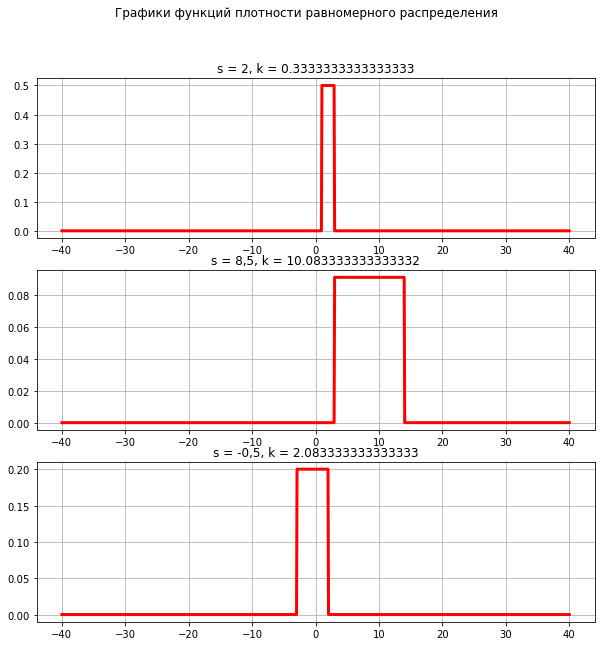

In [35]:
plt.figure(figsize = (10, 10))
plt.suptitle("Графики функций плотности равномерного распределения")
plt.subplot(3, 1, 1)
plt.plot(x, Raspred_1, lw = 3, color = 'r')
plt.title('s = 2, k = 0.3333333333333333')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(x, Raspred_2, lw = 3, color = 'r')
plt.title('s = 8,5, k = 10.083333333333332')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(x, Raspred_3, lw = 3, color = 'r')
plt.title('s = -0,5, k = 2.083333333333333')
plt.grid(True)

Из графиков видно что коэффициент асимметрии s показывает симметричность графика плотности распределения графика относительно оси OY. Если он симметричен: s = 0, если он сдвинут вправо: s > 0, если он сдвинут влево: s < 0. $\newline$
Коэффициент эксцесса k показывает, насколько широкая(пологая) вершина графика: чем он больше, тем положе вершина.

Теперь посмотрим на нормальное распределение: введём случайные величины $Y_1, Y_2$ и $Y_3$: $$Y_1 \sim N(0, 1) \newline Y_2 \sim N(2, 10) \newline Y_3 \sim N(-2, 4)$$

In [36]:
y = np.linspace(-40, 40, 1000)

Y_1 = sts.norm(0, 1)
Y_2 = sts.norm(2, 10)
Y_3 = sts.norm(-2, 5)

sk1 = Y_1.stats('mvsk')[:2]
sk2 = Y_2.stats('mvsk')[:2]
sk3 = Y_3.stats('mvsk')[:2]

Raspred_1 = Y_1.pdf(x)
Raspred_2 = Y_2.pdf(x)
Raspred_3 = Y_3.pdf(x)

print('Коэффициент асимметрии 1-го распределения равен', sk1[0])
print('Коэффициент эксцесса 1-го распределения равен', sk1[1], '\n')

print('Коэффициент асимметрии 2-го распределения равен', sk2[0])
print('Коэффициент эксцесса 2-го распределения равен', sk2[1], '\n')

print('Коэффициент асимметрии 3-го распределения равен', sk3[0])
print('Коэффициент эксцесса 3-го распределения равен', sk3[1], '\n')

Коэффициент асимметрии 1-го распределения равен 0.0
Коэффициент эксцесса 1-го распределения равен 1.0 

Коэффициент асимметрии 2-го распределения равен 2.0
Коэффициент эксцесса 2-го распределения равен 100.0 

Коэффициент асимметрии 3-го распределения равен -2.0
Коэффициент эксцесса 3-го распределения равен 25.0 



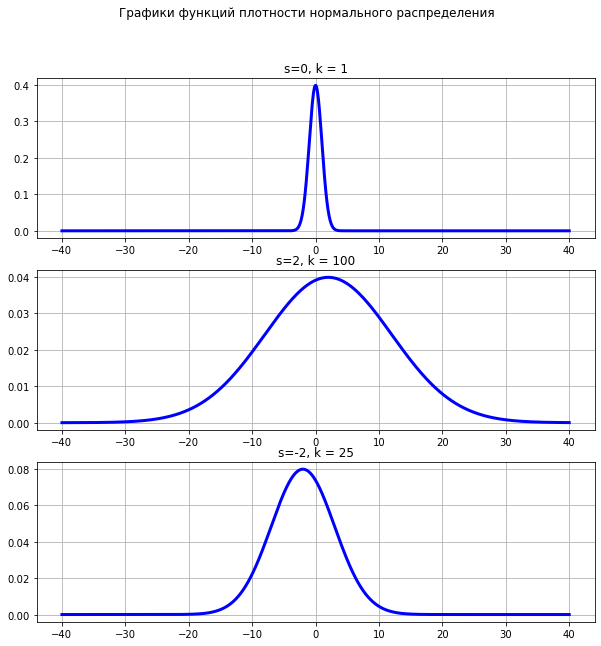

In [37]:
plt.figure(figsize = (10, 10))
plt.suptitle("Графики функций плотности нормального распределения")
plt.subplot(3, 1, 1)
plt.plot(y, Raspred_1, lw = 3, color = 'b')
plt.title('s=0, k = 1')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(y, Raspred_2, lw = 3, color = 'b')
plt.title('s=2, k = 100')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(y, Raspred_3, lw = 3, color = 'b')
plt.title('s=-2, k = 25')
plt.grid(True)

Аналогичный вывод можно сделеать и по этои графикам